In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
path="/content/drive/MyDrive/Nat_Gas.csv"
df=pd.read_csv(path)
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     object 
 1   Prices  48 non-null     float64
dtypes: float64(1), object(1)
memory usage: 900.0+ bytes


In [ ]:
#Convert date column to datetime
df['Dates'] = pd.to_datetime(df['Dates'])

/tmp/ipython-input-2396790329.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


In [ ]:
df.set_index('Dates', inplace=True)

In [ ]:
#Monthly frequency
df = df.asfreq('ME')

In [ ]:
df.head()

,Prices
Dates,
2020-10-31,10.1
2020-11-30,10.3
2020-12-31,11.0
2021-01-31,10.9
2021-02-28,10.9


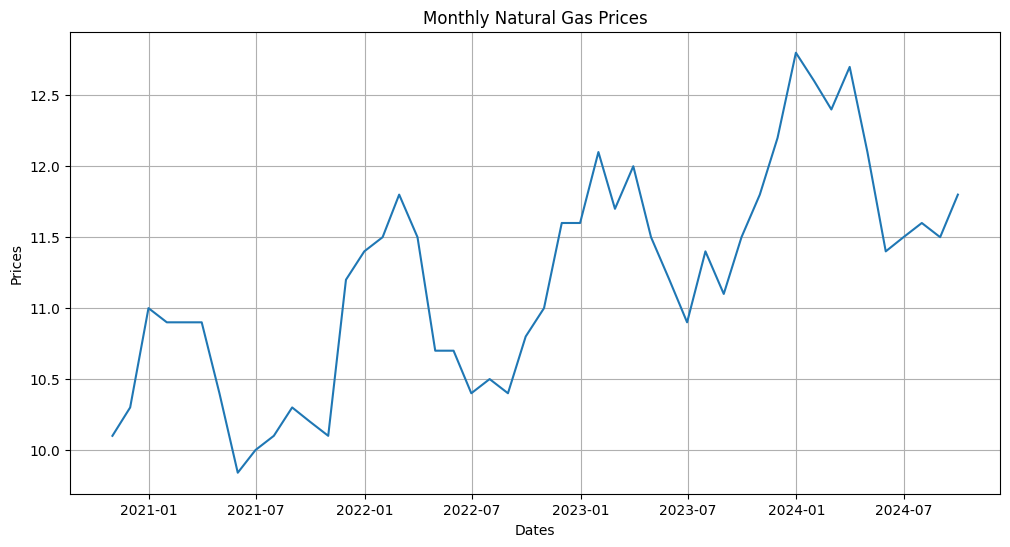

In [ ]:
#Visualizing the data
plt.figure(figsize=(12,6))
plt.plot(df['Prices'])
plt.title("Monthly Natural Gas Prices")
plt.xlabel("Dates")
plt.ylabel("Prices")
plt.grid(True)
plt.show()

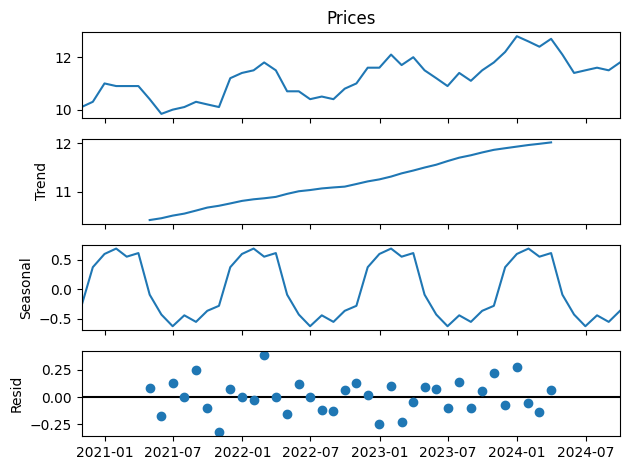

In [ ]:
#Decomposing the time series
decomposition = seasonal_decompose(df['Prices'], model='additive')

decomposition.plot()
plt.show()

In [ ]:
#Forecasting model
model = ExponentialSmoothing(
    df['Prices'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

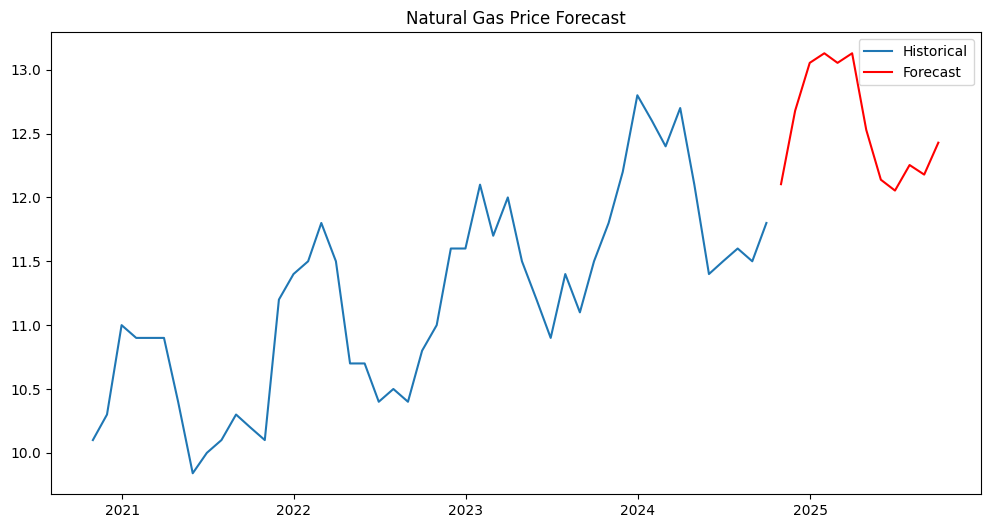

In [ ]:
#Forecasting 1 year
forecast = model.forecast(12)

plt.figure(figsize=(12,6))
plt.plot(df['Prices'], label='Historical')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("Natural Gas Price Forecast")
plt.show()

In [ ]:
#Price estimation
def get_prices_estimate(input_date):
    input_date = pd.to_datetime(input_date)

    if input_date in full_series.index:
        return float(full_series.loc[input_date])

    else:
        temp_series = full_series.resample('D').interpolate()

        if input_date in temp_series.index:
            return float(temp_series.loc[input_date])
        else:
            return "Date out of supported range."

In [ ]:
full_series = pd.concat([df['Prices'], forecast])

print(get_prices_estimate("2023-05-31"))   # historical
print(get_prices_estimate("2025-03-31"))   # forecasted

11.2
13.128751394213287


**Conclusion**

In this project, I have analyzed monthly natural gas prices to identify trend and seasonal patterns. Using Holt-Winters time series forecasting, modeled historical data and projected prices for an additional year.

The solution includes a function that estimates the gas purchase price for any given date, covering both historical and forecasted periods.

Overall, the project demonstrates time series analysis, forecasting, and building pricing estimation tool.

In [ ]:
#Monthly price series
dates = pd.date_range(start="2023-01-31", periods=24)
prices = np.linspace(8, 12, 24)

price_series = pd.Series(prices, index=dates)

def get_prices_estimate(date):
    date = pd.to_datetime(date)
    daily_series = price_series.resample('D').interpolate()
    return float(daily_series.loc[date])

In [ ]:
#Pricing
def price_storage_contract(
    injection_dates,
    withdrawal_dates,
    injection_rate,
    withdrawal_rate,
    max_storage_volume,
    storage_cost_per_unit
):

    current_storage = 0
    total_purchase_cost = 0
    total_sales_revenue = 0
    total_storage_cost = 0

    # Sorting all event dates
    all_dates = sorted(
        [(pd.to_datetime(d), "inject") for d in injection_dates] +
        [(pd.to_datetime(d), "withdraw") for d in withdrawal_dates]
    )

    for date, action in all_dates:
        price = get_prices_estimate(date)

        if action == "inject":
            volume = min(injection_rate, max_storage_volume - current_storage)
            current_storage += volume
            total_purchase_cost += volume * price

        elif action == "withdraw":
            volume = min(withdrawal_rate, current_storage)
            current_storage -= volume
            total_sales_revenue += volume * price

        # Storage cost applies to current stored gas
        total_storage_cost += current_storage * storage_cost_per_unit

    contract_value = total_sales_revenue - total_purchase_cost - total_storage_cost

    return contract_value

In [ ]:
#Re-defining full_series and get_prices_estimate to ensure correct pricing logic is used.
full_series = pd.concat([df['Prices'], forecast])

def get_prices_estimate(input_date):
    input_date = pd.to_datetime(input_date)

    #Checking if the date exists directly in the full_series index
    if input_date in full_series.index:
        return float(full_series.loc[input_date])

    else:
        #If not, resample to daily frequency and interpolate to find the price
        temp_series = full_series.resample('D').interpolate()

        if input_date in temp_series.index:
            return float(temp_series.loc[input_date])
        else:
            return "Date out of supported range."

#Sample inputs
injection_dates = ["2023-02-15", "2023-03-15"]
withdrawal_dates = ["2023-07-15", "2023-08-15"]

contract_value = price_storage_contract(
    injection_dates=injection_dates,
    withdrawal_dates=withdrawal_dates,
    injection_rate=1000,
    withdrawal_rate=1000,
    max_storage_volume=2000,
    storage_cost_per_unit=0.02
)

print("Contract Value:", contract_value)

Contract Value: -1414.1013824884794



**Conclusion**

Built a prototype storage pricing model that calculates contract value by accounting for injection costs, withdrawal revenues, storage expenses, and operational constraints. This provides a framework for evaluating storage strategies and can be further refined for automated pricing in production.